In [ ]:
import numpy as np
import methods as m 
import integrate as integ
import matplotlib.pyplot as plt

DEVO IMPLEMENTARE I MULTI STEP E SISTEMARE DUE COSINE

In [ ]:
def deriv(t, y, args=None, extra_par=None):
    return -y

In [ ]:
t_0 = 0
y_0 = 1
IC = np.array([y_0])

t_start = 0
t_finale = 1
t_range = (t_start, t_finale)

y_methods = []
t_methods = []

methods = [m.forward_euler, m.backward_euler, m.explicit_midpoint, m.Heun, m.RK4]

h = tuple([0.2, 0.1, 0.05, 0.025, 0.0125])

for h_i in h:
    for method in methods:

        t, y = integ.integrate(deriv, t_range, IC, h_i, args=None, method=method, extra_par=None)
        y_methods.append(y)
        t_methods.append(t)









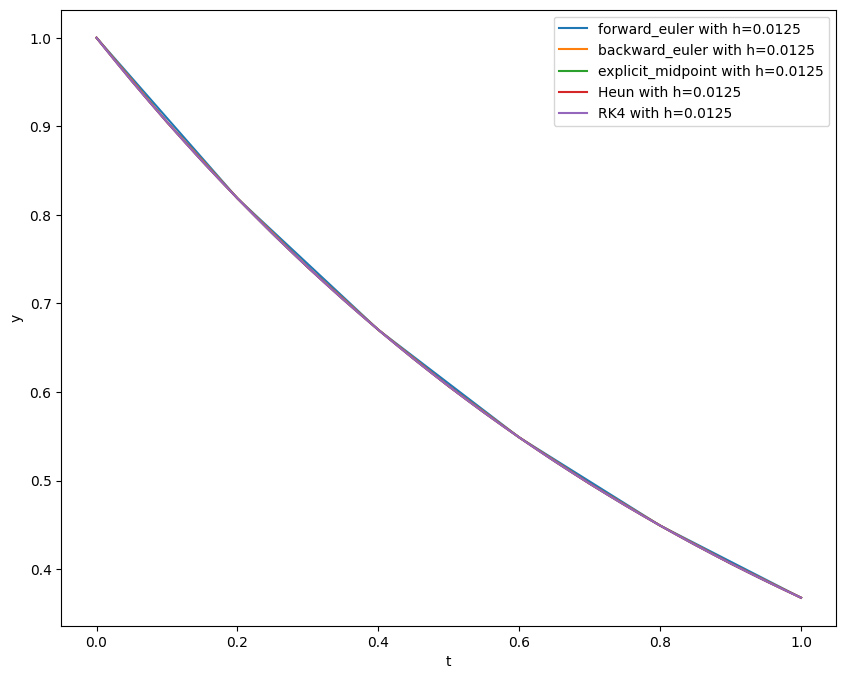

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_xlabel('t')
ax.set_ylabel('y')

for i in range(len(methods)):
    for j in range(len(h)):
        method = methods[i]
        h_i = h[j]
        if h_i == 0.0125:
            label = method.__name__ + ' with h=' + str(h_i)
            ax.plot(t_methods[i*len(h)+j], y_methods[i*len(h)+j], label=label)

ax.legend()
plt.show()


In [ ]:
def f_true(t):
    return np.exp(-t)

y_true = f_true(1)

print(y_true)


0.36787944117144233


In [ ]:
results = []

for i in range( len(h)*len(methods)):
    results.append(y_methods[i][-1])

global_errors = results - y_true


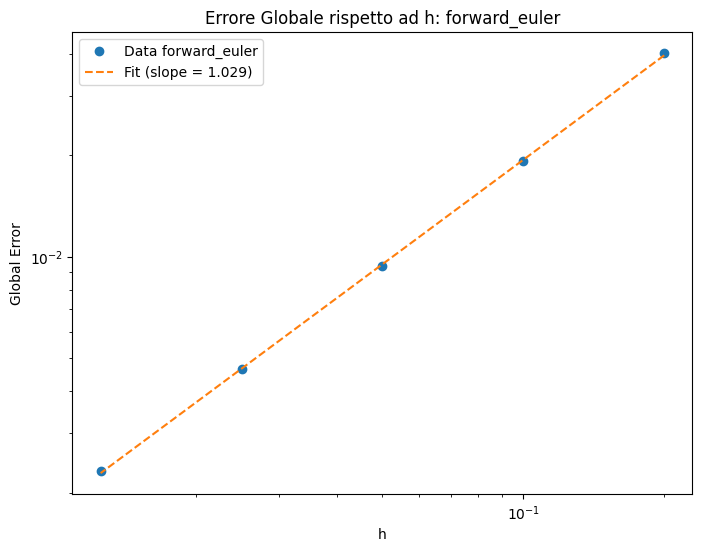

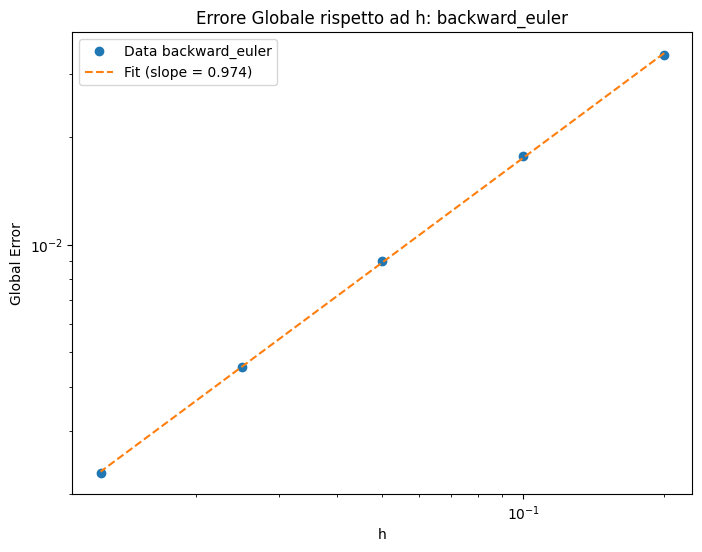

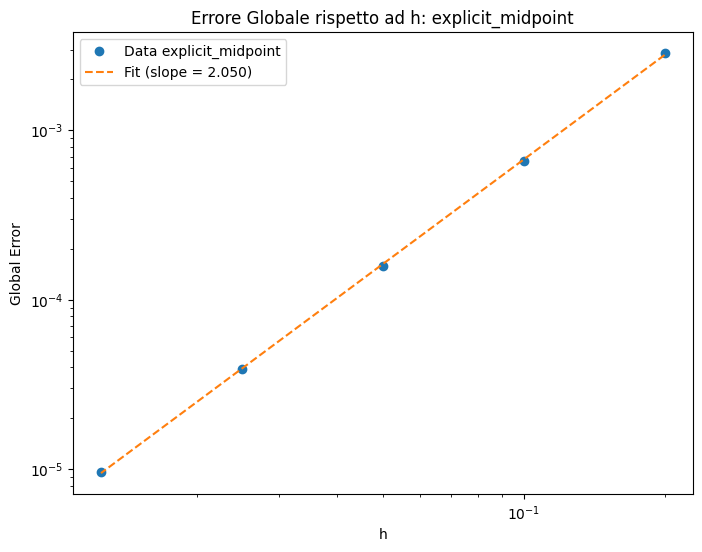

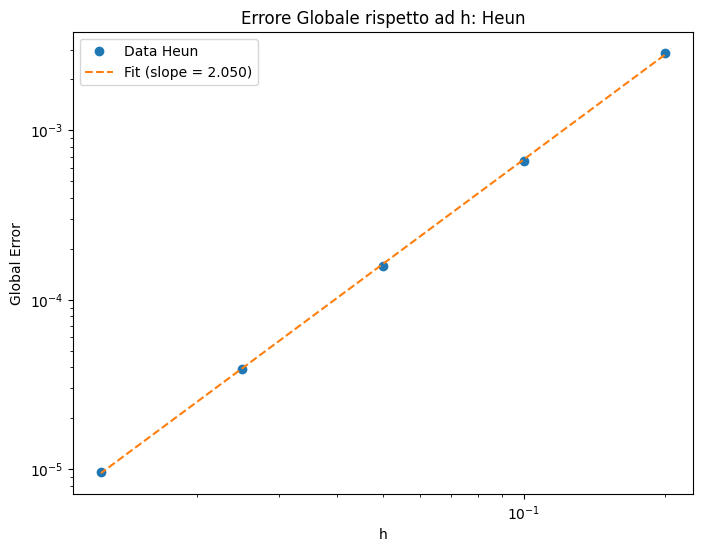

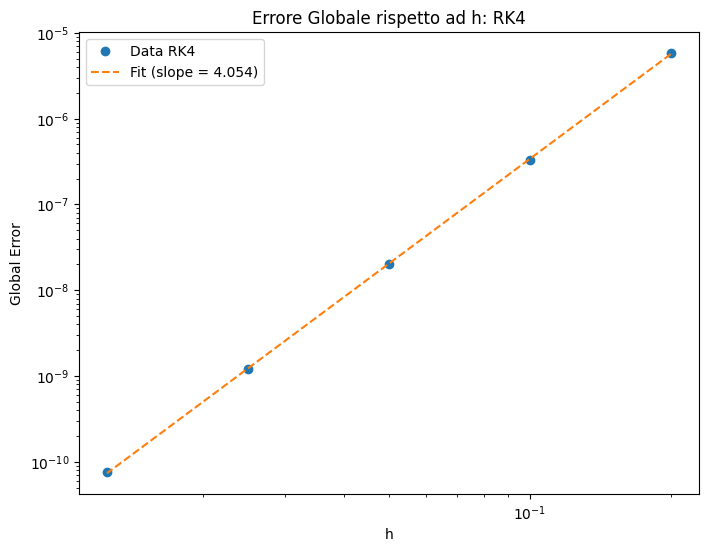

In [ ]:

for i in range(len(methods)):
    method = methods[i]

    x = np.array(h)
    y = np.ravel(np.abs(global_errors[i::len(methods)]))
    
    slope, intercept = np.polyfit(np.log(x), np.log(y), 1)
    y_line = np.exp(intercept) * (x ** slope)
    
    fig, ax = plt.subplots(figsize=(8,6))
    
    ax.plot(x, y, label=f'Data {method.__name__}', marker='o', linestyle='none')
    ax.plot(x, y_line, label=f'Fit (slope = {slope:.3f})', linestyle='--')

    ax.set_title(f'Errore Globale rispetto ad h: {method.__name__}')
    ax.set_xlabel('log h')
    ax.set_ylabel('log Global Error')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
    plt.show()